## What is Adam Optimizer?


Adam (Adaptive Moment Estimation) optimizer combines the advantages of Momentum and RMSprop techniques to adjust learning rates during training. It works well with large datasets and complex models because it uses memory efficiently and adapts the learning rate for each parameter automatically.

## How Does Adam Work?

Adam computes adaptive learning rates for each parameter by keeping track of the first and second moments of the gradients. The first moment (mean) is calculated as an exponentially decaying average of past gradients, while the second moment (uncentered variance) is calculated as an exponentially decaying average of the squares of past gradients.

The update rule for Adam is as follows:

```m_t = β1 * m_{t-1} + (1 - β1) * g_t```

```v_t = β2 * v_{t-1} + (1 - β2) * g_t^2```

```m̂_t = m_t / (1 - β1^t)```

```v̂_t = v_t / (1 - β2^t)```

```θ_t = θ_{t-1} - α * m̂_t / (sqrt(v̂_t) + ε)```

Where:
- `m_t` is the first moment (mean) of the gradients at time step `t`.
- `v_t` is the second moment (uncentered variance) of the gradients at time step `t`.
- `β1` and `β2` are the decay rates for the first and second moments, respectively.
- `g_t` is the gradient at time step `t`.
- `α` is the learning rate.
- `ε` is a small constant to prevent division by zero.  

Adam builds upon two key concepts in optimization:

1. **Momentum**: This technique helps accelerate gradients in the right direction, leading to faster convergence. It does this by maintaining a moving average of past gradients, which helps to smooth out updates and reduce oscillations.

2. **RMSprop**: This technique adjusts the learning rate for each parameter based on the magnitude of recent gradients. It divides the learning rate by an exponentially decaying average of squared gradients, which helps to stabilize updates and prevent divergence. 

### Combining Momentum and RMSprop to form Adam Optimizer

Adam combines the benefits of both Momentum and RMSprop by maintaining both the first moment (mean) and second moment (uncentered variance) of the gradients. This allows Adam to adapt the learning rate for each parameter based on the historical gradients, while also accelerating convergence through momentum.

First moment (mean) estimate:

```m_t = β1 * m_{t-1} + (1 - β1) * g_t```

Second moment (uncentered variance) estimate:

```v_t = β2 * v_{t-1} + (1 - β2) * g_t^2```

Bias-corrected first moment estimate:

```m̂_t = m_t / (1 - β1^t)```

Bias-corrected second moment estimate:

```v̂_t = v_t / (1 - β2^t)```

Parameter update rule:

```θ_t = θ_{t-1} - α * m̂_t / (sqrt(v̂_t) + ε)```

Where:
- `m_t` is the first moment (mean) of the gradients at time step `t`.
- `v_t` is the second moment (uncentered variance) of the gradients at time step `t`.
- `β1` and `β2` are the decay rates for the first and second moments, respectively.
- `g_t` is the gradient at time step `t`.
- `α` is the learning rate.
- `ε` is a small constant to prevent division by zero.  

## Why Adam Works So Well?

Adam addresses several challenges of gradient descent optimization:

* Dynamic learning rates: Each parameter has its own adaptive learning rate based on past gradients and their magnitudes. This helps the optimizer avoid oscillations and get past local minima more effectively.
* Bias correction: By adjusting for the initial bias when the first and second moment estimates are close to zero helping to prevent early-stage instability.
* Efficient performance: Adam typically requires fewer hyperparameter tuning adjustments compared to other optimization algorithms like SGD making it a more convenient choice for most problems.

## Performance of Adam

In comparison to other optimizers like SGD (Stochastic Gradient Descent) and momentum-based SGD, Adam outperforms them significantly in terms of both training time and convergence accuracy. Its ability to adjust the learning rate per parameter combined with the bias-correction mechanism leading to faster convergence and more stable optimization. This makes Adam especially useful in complex models with large datasets as it avoids slow convergence and instability while reaching the global minimum.

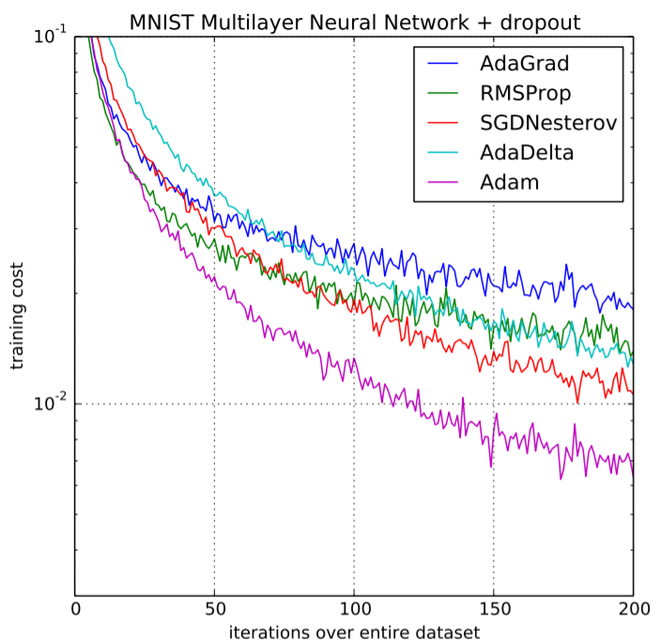




## Adam Optimizer in Tensorflow

Adam (Adaptive Moment Estimation) is an optimizer that combines the best features of two optimizers i.e Momentum and RMSprop. Adam is used in deep learning due to its efficiency and adaptive learning rate capabilities.

* **learning_rate:** The learning rate to use in the algorithm (default value: 0.001).
* **beta_1:** The exponential decay rate for the 1st moment estimates (default value: 0.9).
* **beta_2:** The exponential decay rate for the 2nd moment estimates (default value: 0.999).
* **epsilon:** A small constant for numerical stability (default value: 1e-7).
* **amsgrad:** A boolean flag to specify whether to apply the AMSGrad variant (default value: False).
* **name:** Optional name for the operations created when applying gradients (default value: 'Adam').

## Using Adam Optimizer in TensorFlow


### 1. Creating the Model

In [1]:
import tensorflow as tf


def createModel(input_shape):
    X_input = tf.keras.layers.Input(input_shape)
    X = tf.keras.layers.Dense(10, activation='relu')(X_input)
    X_output = tf.keras.layers.Dense(2, activation='softmax')(X)
    model = tf.keras.Model(inputs=X_input, outputs=X_output)
    return model

In [2]:
model = createModel((10, 10))
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10, 10)         │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10, 2)          │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132 (528.00 B)

 Trainable params: 132 (528.00 B)

 Non-trainable params: 0 (0.00 B)

None


### 2. Checking Initial Weights

In [3]:
print('Initial Layer Weights')
for i in range(1, len(model.layers)):
    print(f'Weight for Layer {i}:')
    print(model.layers[i].get_weights()[0])
    print()

Initial Layer Weights
Weight for Layer 1:
[[ 0.4919194  -0.50888515 -0.4717772   0.27521324  0.00112671 -0.145832
   0.43955076 -0.41995406  0.27466428  0.19712877]
 [ 0.4291708   0.49524128 -0.39197928  0.05123997  0.2176764  -0.18998733
   0.21241593  0.2947675   0.48249173 -0.34599507]
 [ 0.38724512 -0.43449938  0.15478843 -0.2711934   0.4785806  -0.05910757
  -0.3464712  -0.3046587  -0.09432617  0.44928473]
 [ 0.5193349  -0.54538     0.24087733  0.45006764  0.03862965 -0.37985188
  -0.26609656 -0.20508334  0.1180523   0.00553012]
 [-0.4667423   0.5061283   0.1596514   0.43595833  0.02054632 -0.41141132
   0.3198136  -0.33765173  0.06301969 -0.543286  ]
 [-0.3862845   0.14829618 -0.47112128  0.05294478 -0.1980097   0.52299404
   0.5188285  -0.24679291  0.29328692  0.04538888]
 [ 0.21842426 -0.21686909  0.32380778 -0.30329055 -0.06966203  0.3525278
   0.17371929  0.4635539  -0.12098306  0.5218744 ]
 [ 0.32620835 -0.35502204 -0.05130693  0.35064006 -0.33365667  0.03184044
  -0.1937639

### 3. Generating Dummy Data 

In [4]:
tf.random.set_seed(5)

X = tf.random.normal((2, 10, 10))
Y = tf.random.normal((2, 10, 2))

### 4. Compiling Model

In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(model.optimizer.get_config())

{'name': 'adam', 'learning_rate': 0.0010000000474974513, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


In [6]:
model.fit(X, Y)

print('Final Layer Weights')
for i in range(1, len(model.layers)):
    print(f'Weight for Layer {i}:')
    print(model.layers[i].get_weights()[0])
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step - accuracy: 0.5500 - loss: -0.1254
Final Layer Weights
Weight for Layer 1:
[[ 4.90919501e-01 -5.07885158e-01 -4.70777214e-01  2.76213139e-01
   2.12658639e-03 -1.44832060e-01  4.38550770e-01 -4.18954611e-01
   2.73664385e-01  1.96128801e-01]
 [ 4.28170860e-01  4.96241271e-01 -3.90979290e-01  5.22398837e-02
   2.18676299e-01 -1.90986618e-01  2.11415991e-01  2.95767456e-01
   4.81491774e-01 -3.46995026e-01]
 [ 3.86245161e-01 -4.33499426e-01  1.55788362e-01 -2.72192597e-01
   4.79580551e-01 -6.01075441e-02 -3.47471118e-01 -3.03658724e-01
  -9.33264941e-02  4.48284745e-01]
 [ 5.20334899e-01 -5.44380009e-01  2.41877317e-01  4.49067742e-01
   3.76296788e-02 -3.78851891e-01 -2.65096575e-01 -2.06083298e-01
   1.19052276e-01  6.53009862e-03]
 [-4.65742409e-01  5.07128060e-01  1.58651441e-01  4.34958398e-01
   1.95463747e-02 -4.10411328e-01  3.18813622e-01 -3.38651717e-01
   6.40196130e-02 -5.42286038e-01]
 [-3.87284458e-01  1.47296220e-01 -4.72121239e-01  